In [2]:
%pip install torch torchvision --quiet
%pip install ftfy regex tqdm --quiet
%pip install matplotlib --quiet
%pip install git+https://github.com/openai/CLIP.git --quiet

import torch
import clip
from PIL import Image
from IPython.display import display
import glob
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print(f"Using device: {device}")


Using device: mps


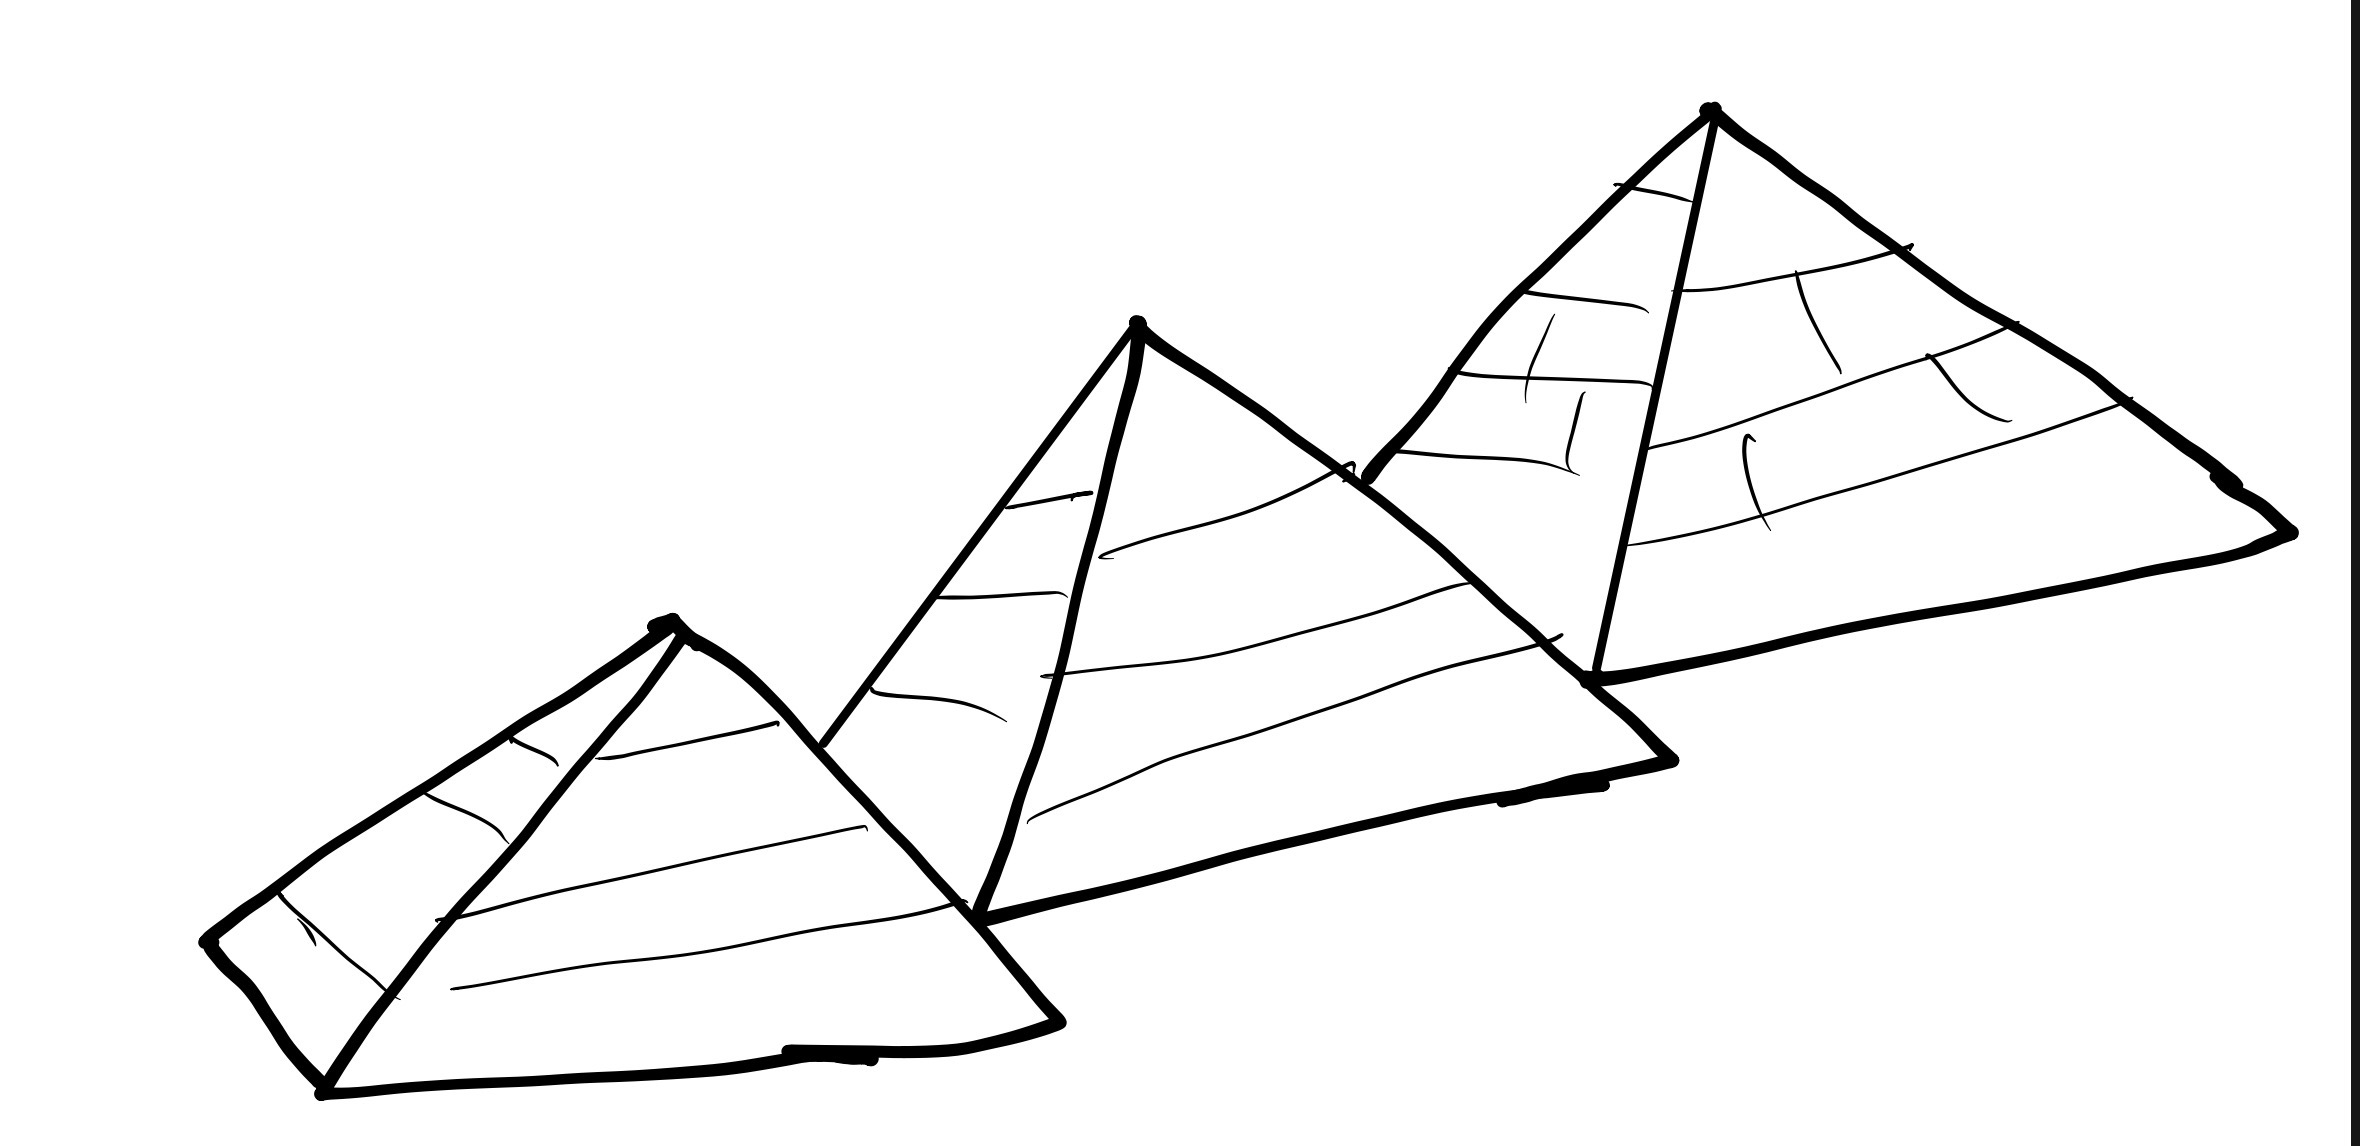

In [5]:
# Update this path to point to your sketch image
sketch_path = "pyramid-mid.jpg"

display(Image.open(sketch_path))


In [6]:
# Zero-shot classification: what does the sketch depict?
image_input = preprocess(Image.open(sketch_path)).unsqueeze(0).to(device)

text_labels = [
    "a pyramid",
    "a mosque",
    "a temple",
    "a palace",
    "a bridge",
    "a museum",
    "a beach",
    "a stadium",
]
text_tokens = clip.tokenize(text_labels).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image_input, text_tokens)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

for label, prob in zip(text_labels, probs[0]):
    print(f"  {label}: {prob:.4f}")


  a pyramid: 0.9990
  a mosque: 0.0000
  a temple: 0.0003
  a palace: 0.0002
  a bridge: 0.0001
  a museum: 0.0001
  a beach: 0.0001
  a stadium: 0.0000


In [7]:
# Load clean index (diagrams pre-filtered in phase 0)
image_features = torch.load("embeddings/image_features_clean.pt", weights_only=True).to(device)
with open("embeddings/image_paths_clean.pkl", "rb") as f:
    image_paths = pickle.load(f)

print(f"Loaded {len(image_paths)} clean image embeddings.")


Loaded 4923 clean image embeddings.


In [8]:
# Encode the query sketch for retrieval
sketch = preprocess(Image.open(sketch_path)).unsqueeze(0).to(device)

with torch.no_grad():
    sketch_features = model.encode_image(sketch)
    sketch_features /= sketch_features.norm(dim=-1, keepdim=True)

print("Sketch feature shape:", sketch_features.shape)


Sketch feature shape: torch.Size([1, 512])


In [9]:
# Encode user text query
text_query = input("Enter a text query (or press Enter to skip): ").strip()

with torch.no_grad():
    if text_query:
        text_tokens = clip.tokenize([text_query]).to(device)
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        print(f"Text query: '{text_query}'")
        print(f"Text features shape: {text_features.shape}")
    else:
        text_features = None
        print("No text query — using sketch only.")


Text query: 'ancient pyramid'
Text features shape: torch.Size([1, 512])


In [10]:
# Fuse sketch + text embeddings via weighted interpolation
# alpha=1.0 → sketch only | alpha=0.0 → text only
alpha = 0.3

if text_features is not None:
    fused_features = alpha * sketch_features + (1 - alpha) * text_features
    fused_features /= fused_features.norm(dim=-1, keepdim=True)
    print(f"Using fused query  (sketch weight={alpha}, text weight={round(1-alpha, 2)})")
else:
    fused_features = sketch_features
    print("Using sketch-only query")


Using fused query  (sketch weight=0.3, text weight=0.7)


In [11]:
# Compute cosine similarities and retrieve top-k matches
similarities = (fused_features @ image_features.T).cpu().numpy()
print("Similarities shape:", similarities.shape)

top_k = 5
top_indices = similarities.argsort()[0][-top_k:][::-1]

print(f"\nTop {top_k} matches:")
for idx in top_indices:
    print(f"  [{idx}] {image_paths[idx]}  (score: {similarities[0][idx]:.4f})")


Similarities shape: (1, 4923)

Top 5 matches:
  [509] dataset/images/Pyramid_of_Menkaure/24.jpg  (score: 0.5342)
  [4326] dataset/images/Bent_Pyramid/1.jpg  (score: 0.5337)
  [1097] dataset/images/Red_Pyramid/19.jpg  (score: 0.5322)
  [1091] dataset/images/Red_Pyramid/22.jpg  (score: 0.5293)
  [4162] dataset/images/Pyramid_of_Neferirkare/2.jpg  (score: 0.5283)


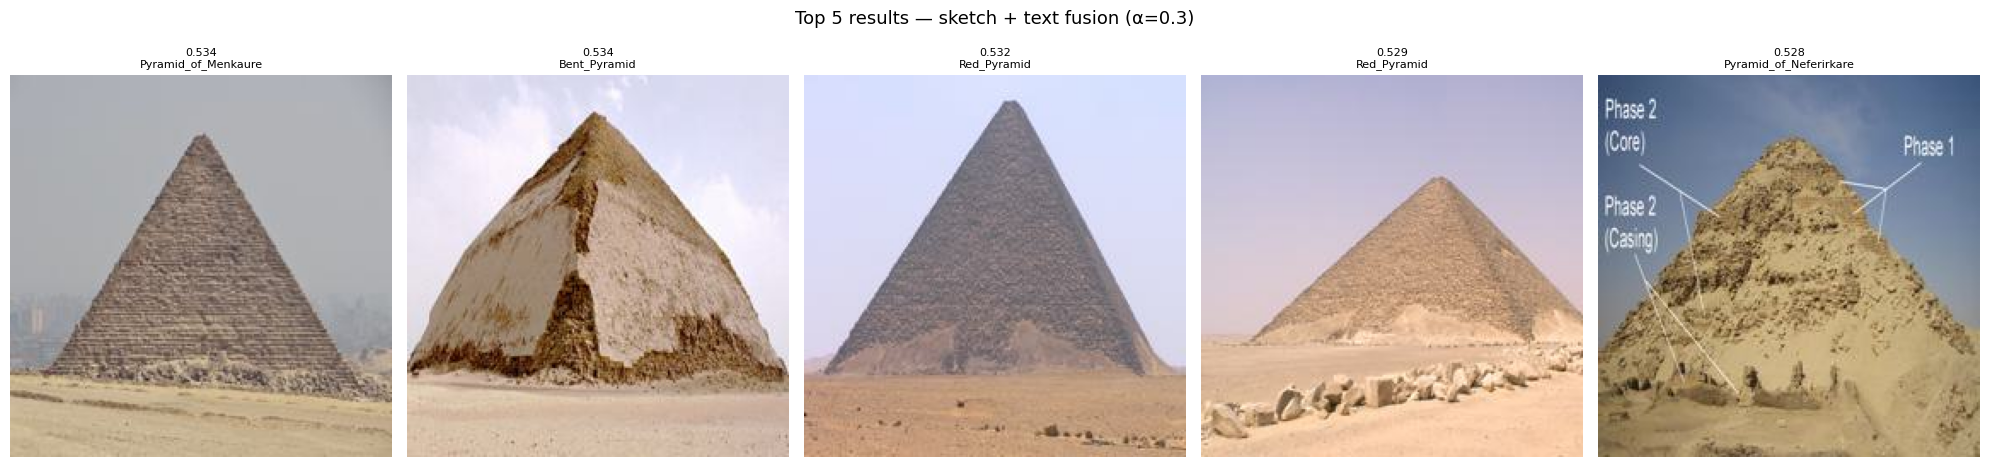

In [12]:
# Display top results as a grid
top_k = 5
fig, axes = plt.subplots(1, top_k, figsize=(20, 5))
for i, idx in enumerate(top_indices):
    path = image_paths[idx]
    class_name = path.split("/")[-2]
    score = similarities[0][idx]
    try:
        axes[i].imshow(mpimg.imread(path))
        axes[i].set_title(f"{score:.3f}\n{class_name[:22]}", fontsize=8)
        axes[i].axis("off")
    except Exception:
        axes[i].axis("off")

plt.suptitle(f"Top {top_k} results — sketch + text fusion (α={alpha})", fontsize=13)
plt.tight_layout()
plt.show()
